# Лабораторная работа: MLflow и предсказание стоимости медицинской страховки
Используем датасет `insurance.csv`. Цель: предсказать `charges` на основе возраста, пола, ИМТ, количества детей, статуса курения и региона.

In [1]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from mlflow.models import infer_signature
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("MLflow Version:", mlflow.__version__)

MLflow Version: 3.11.1


## 1. Загрузка и предобработка данных

In [2]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Кодирование категориальных признаков (sex, smoker, region)
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df[col] = le.fit_transform(df[col])

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


## 2. Эксперименты в MLflow

In [4]:
def run_insurance_experiment(n_estimators, max_depth, run_name):
    mlflow.set_experiment("Medical_Insurance_Costs")
    
    with mlflow.start_run(run_name=run_name):
        model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_test)
        
        # Метрики
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        
        # Логирование параметров
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)
        
        # Логирование метрик
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("mae", mae)
        
        # Сохранение модели
        signature = infer_signature(X_train, model.predict(X_train))
        mlflow.sklearn.log_model(model, "model", signature=signature)
        
        print(f"[{run_name}] R2: {r2:.3f}, RMSE: {rmse:.2f}")

# Запуск 3 разных конфигураций
run_insurance_experiment(5, 2, "Underfit_Model")     # Слишком простая
run_insurance_experiment(100, 5, "Balanced_Model")   # Оптимальная
run_insurance_experiment(500, 20, "Complex_Model")    # Переобученная

2026/04/15 02:04:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 02:04:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Underfit_Model] R2: 0.839, RMSE: 5005.61


2026/04/15 02:04:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 02:04:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Balanced_Model] R2: 0.873, RMSE: 4448.96


2026/04/15 02:04:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 02:04:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Complex_Model] R2: 0.866, RMSE: 4559.19


## 3. Сравнение и выбор


Лучшая модель: Balanced_Model
Run ID: 1c17240e797842ed8c81395cd6fb93fb


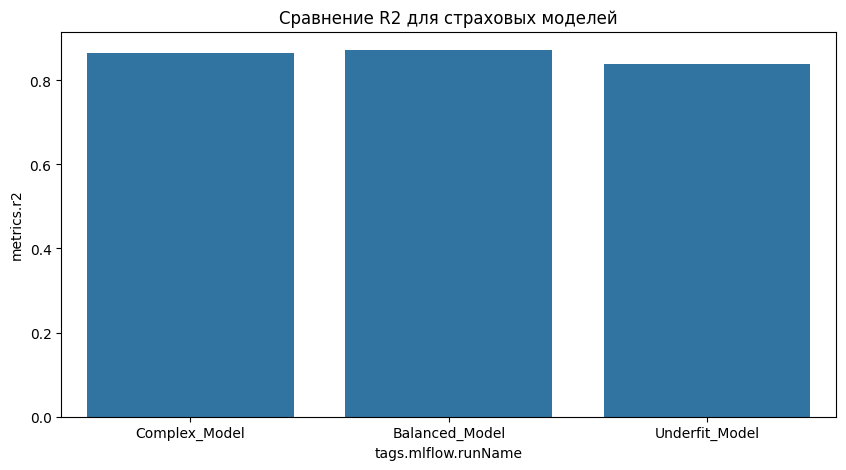

In [5]:
runs = mlflow.search_runs(experiment_names=["Medical_Insurance_Costs"])
best_run = runs.sort_values("metrics.r2", ascending=False).iloc[0]

print(f"\nЛучшая модель: {best_run['tags.mlflow.runName']}")
print(f"Run ID: {best_run['run_id']}")

# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x="tags.mlflow.runName", y="metrics.r2", data=runs)
plt.title("Сравнение R2 для страховых моделей")
plt.show()